# Do IPOs really sink for years after the party? 📉
### Ritter's famous "long-run IPO underperformance" — the pop is for the flippers, the drift is for the bagholders. Is it true? Can you use it?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Small-growth beta?: Confirmed](https://img.shields.io/badge/Small--growth_beta%3F-Confirmed-8b949e?style=flat-square)

Everyone knows the IPO story: a hot company lists, the stock "pops" 20% on day one, CNBC celebrates. Less advertised is the academic sequel, discovered by Jay Ritter in 1991: for the **three to five years after** the party, the average IPO **lags** the rest of the market. The pop goes to the institutions who got allocations; the long slow slide goes to whoever bought in the aftermarket and held.

We test it two ways: Ritter's own continuously-updated scorecard of **9,253 US IPOs over 45 years**, and a **live 12.7-year experiment** — an actual ETF that does nothing but hold recent IPOs (the Renaissance IPO ETF) against the S&P 500.

> 📓 **Plain-language layer.** Want the *t*-stats, HAC lags and cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Cousins on this desk, so we don't double-count: [219-ipo-pop](../../219-ipo-pop/) is the **day-one pop**; [265-ipo-volume](../../265-ipo-volume/) uses IPO **volume as a market-timing signal**. This study is the **multi-year drift** — measured from the first closing price, never the offer price, so the pop is already out of the picture.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ipo_long_run_underperformance import data, strategy as st

COHORTS = data.ritter_cohorts()                    # Track A: always offline (hardcoded)
HAVE_REAL = data.have_real()                       # Track B: cache-first
PANEL = data.monthly_panel(data.load_tape()) if HAVE_REAL else None
print("Ritter cohorts:", len(COHORTS), "| live ETF cache present:", HAVE_REAL,
      "| months:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'fingerprint': '65b022ff4f0e', 'n_cohorts': 45, 'n_ipos': 9253, 'first_day_pct': 18.9, 'raw': (22.5, 3.2, 19.13, 22.2), 'mkt': (-14.2, -2.26, -20.51, 71.1), 'style': (-8.46, -1.52, -8.87, 66.7), 'mkt_extrunc': (-12.03, -2.18), 'style_extrunc': (-6.6, -1.37), 'n_months': 152, 'years': 12.7, 'start': '2013-11-30', 'end': '2026-06-30', 'growth': {'IPO': (3.1, 9.34), 'SPY': (5.27, 14.02), 'IWM': (3.25, 9.74), 'IWO': (3.37, 10.07)}, 'rel_peak': 1.45, 'rel_peak_date': '2021-01', 'rel_end': 0.59, 'rel_dd': -67.5, 'share_beat': 50.0, 'vs_spy': (-16.36, -1.95, -0.31, -46.71, -5.46, -0.99, 1.293), 'vs_iwm': (8.39, 1.01, 0.17, 8.86, 1.07, 0.18, 0.994), 'vs_iwo': (4.79, 0.58, 0.12, 0.23, 0.03, 0.01, 1.055), 'two_factor': (-4.66, -0.56, -0.12, 1.091, 0.999), 'overlay': [(5.0, 1.0, 16.36, 0.31, 7.63, 0.92, 0.15, -57.4), (10.0, 1.0, 16.36, 0.31, 7.23, 0.87, 0.14, -57.5), (5.0, 2.0, 16.36, 0.31, -0.7, -0.08, -0.01, -59.5)], 'syn': [(0.0, 6.31, 0.21, 5.0), (-50.0, -43.69, -1.83, 45.0), (-100.0, -93.69, -3.88, 95.0)]}


Ritter cohorts: 45 | live ETF cache present: True | months: 152


## The answer first

| Question | Answer |
|---|---|
| Did IPOs historically lag the market for 3 years? | **Yes, on the 45-year record.** The average IPO cohort lagged the market by about **−14% over 3 years** — 71% of all cohort years were negative. |
| Is it still detectably true on a live, buyable instrument? | **Not provably.** Over 12.7 years the IPO ETF lagged the S&P (**+9.3%/yr vs +14.0%/yr**) but the gap is statistically indistinguishable from noise. |
| Is "IPO" even the right villain? | **Mostly no.** Compare IPOs to *other* small, fast-growing, expensive stocks and the underperformance essentially **vanishes** — in Ritter's own tables and on the live tape. The sin is the *style*, not the wrapper. |
| Can you make money shorting new listings? | **No.** After borrow fees and costs the short earns ~**+0.9%/yr** of statistical nothing and once drew down **−57%**. |

> The honest version of the legend: *"freshly-listed stocks are usually expensive small-growth stocks, and expensive small-growth is a bad neighbourhood"* — true, but not a money machine, and not really about IPOs.

## 1 · The claim

> *"IPOs underperform seasoned stocks for 3-5 years after listing. The first-day pop is for the flippers; the drift is for the bagholders."*

This is not folklore — it's **Ritter (1991)** and **Loughran & Ritter (1995, *The New Issues Puzzle*)**, two of the most-cited papers in finance, plus a scorecard Ritter still updates every year. The mechanisms offered: IPOs are *sold* (not bought) at peaks of optimism, lockup expiries flood the market with supply, and small investors systematically overpay for lottery-like growth stories.

## 2 · So what?

If true and usable, you should never buy a recent IPO — and maybe short a basket of them. If true but *style-driven*, the lesson changes completely: the problem isn't the IPO stamp, it's that new listings are **small growth stocks bought expensive**, and you'd get the same medicine by avoiding that style anywhere. One claim indicts an *event*; the other indicts a *price tag*. Telling them apart is the whole game — and it's exactly the third axis of this study.

## 3 · How would we even know?

**Track A — the 45-year scorecard.** Ritter tracks every qualifying US IPO (9,253 of them, 1980-2024) for 3 years from its **first closing price** (the pop already excluded), against the market and against **style-matched** seasoned firms (same size, same valuation). One average per cohort year = 45 observations, and we test whether their mean is really below zero (with statistics that respect the overlap between consecutive 3-year windows).

**Track B — the live experiment.** Since 2013 you can *buy* Ritter's aftermarket window: the **Renaissance IPO ETF** holds new listings for ~2-3 years, then drops them. We race its monthly returns (fees included) against SPY, small caps (IWM) and — the style control — small **growth** (IWO), over **12.7 years**.

## 4 · The teardown — let's actually look

**The 45-year record.** Each bar is one IPO vintage: how the average IPO of that year did over the next 3 years, *relative to the market*.

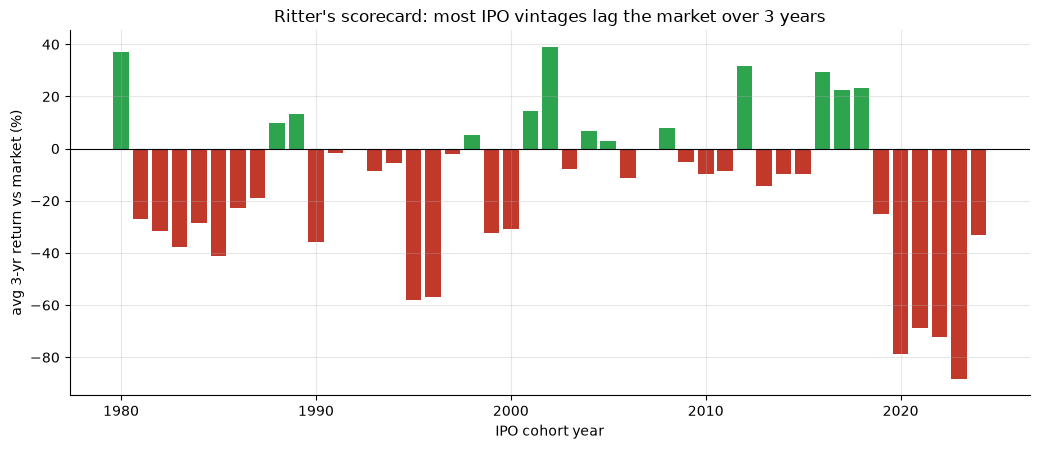

45 cohorts 1980-2024: mean -14.20%/3yr vs market, 71.1% negative


In [2]:
x = COHORTS['bhr3_mkt_adj']
fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.bar(x.index, x.values, color=[RED if v < 0 else GREEN for v in x.values], width=.8)
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('IPO cohort year'); ax.set_ylabel('avg 3-yr return vs market (%)')
ax.set_title('Ritter\'s scorecard: most IPO vintages lag the market over 3 years')
plt.tight_layout(); plt.show()
neg = (x < 0).mean() * 100
print(f'{len(x)} cohorts 1980-2024: mean {x.mean():+.2f}%/3yr vs market, {neg:.1f}% negative')

A sea of red: **71% of the 45 vintages** lagged the market, averaging **-14.2% over 3 years** (weighted by IPO counts: -20.5%). The quants notebook confirms this clears the significance bar even after accounting for overlapping windows. So the *history* is real.

**But now the style question.** Ritter also compares each IPO to a *seasoned* stock of the same size and valuation — a small-growth doppelgänger that simply isn't a new listing. Watch the drag shrink:

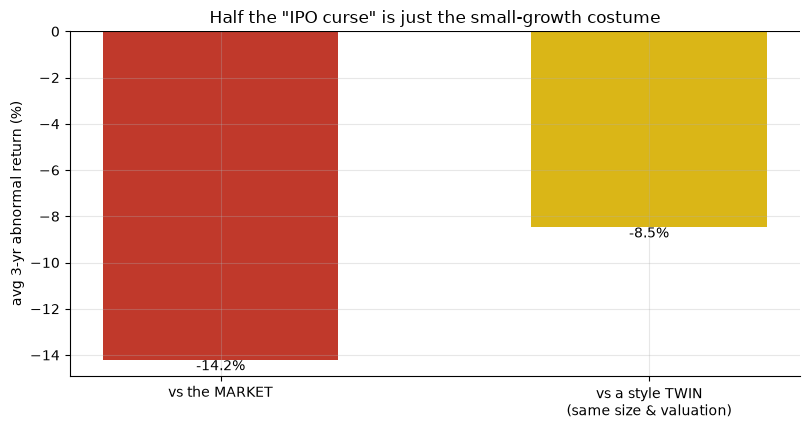

market-adjusted -14.2%/3yr  ->  style-adjusted -8.5%/3yr


In [3]:
vals = [R['mkt'][0], R['style'][0]]
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['vs the MARKET', 'vs a style TWIN\n(same size & valuation)'], vals,
       color=[RED, AMBER], width=.55)
for i, v in enumerate(vals): ax.annotate(f'{v:+.1f}%', (i, v), ha='center', va='top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('avg 3-yr abnormal return (%)')
ax.set_title('Half the "IPO curse" is just the small-growth costume')
plt.tight_layout(); plt.show()
print(f'market-adjusted {vals[0]:+.1f}%/3yr  ->  style-adjusted {vals[1]:+.1f}%/3yr')

Against its style twin, the average IPO lags by only **-8.5%/3yr** — and (quants notebook) that residual is **no longer statistically distinguishable from zero**. Brav & Gompers made exactly this point in 1997: small growth stocks that *didn't* just IPO do about as badly.

**The live experiment.** Since 2013, $1 in the IPO ETF vs $1 in SPY vs $1 in the small-growth index fund:

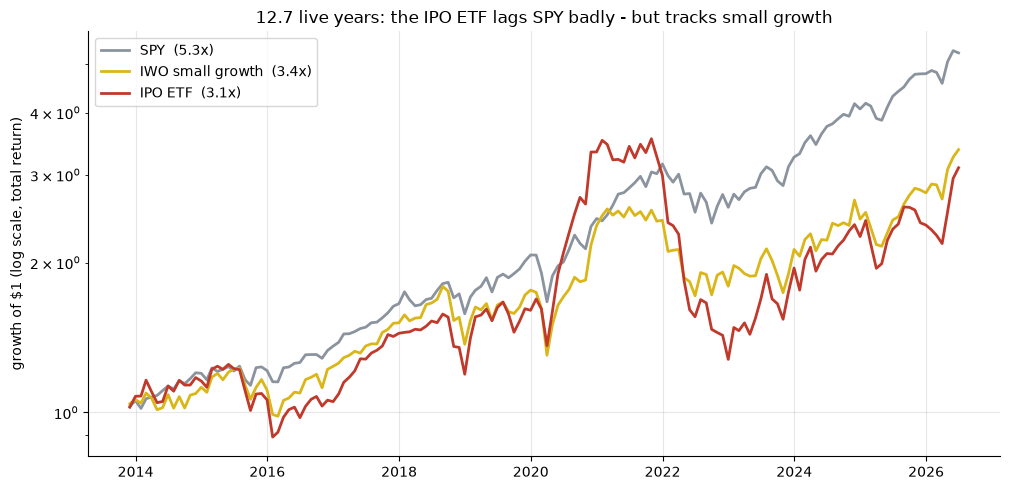

IPO: 3.10x
SPY: 5.27x
IWM: 3.25x
IWO: 3.37x


In [4]:
if HAVE_REAL:
    nav = np.exp(np.log1p(PANEL[['IPO','SPY','IWO']]).cumsum())
    fig, ax = plt.subplots(figsize=(10.2, 5.0))
    ax.plot(nav.index, nav['SPY'], c=GREY, lw=2, label=f"SPY  ({R['growth']['SPY'][0]:.1f}x)")
    ax.plot(nav.index, nav['IWO'], c=AMBER, lw=2, label=f"IWO small growth  ({R['growth']['IWO'][0]:.1f}x)")
    ax.plot(nav.index, nav['IPO'], c=RED, lw=2, label=f"IPO ETF  ({R['growth']['IPO'][0]:.1f}x)")
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log scale, total return)')
    ax.set_title('12.7 live years: the IPO ETF lags SPY badly - but tracks small growth')
    ax.legend(); plt.tight_layout(); plt.show()
    for c in ('IPO','SPY','IWM','IWO'):
        print(f"{c}: {st.cumulative_growth(PANEL, c):.2f}x")
else:
    print('(cache missing - frozen numbers)', {k: v[0] for k, v in R['growth'].items()})

The IPO ETF turned $1 into **3.1×** (+9.3%/yr) while SPY made **5.3×** (+14.0%/yr) — it even briefly reached **1.45× SPY's wealth** in the 2020-21 mania before a **-68%** relative collapse. Yet it beat SPY in **50% of months** — a coin flip — and the small-growth fund IWO landed at almost the same place (3.4×). The quants notebook shows the lag is **statistically noise** vs SPY (*t* ≈ −1) and exactly **zero** vs small growth. And shorting it? After borrow fees you keep ~**+0.9%/yr** of nothing, having survived a −57% drawdown.

## 5 · The verdict

- **Signal — Weak.** The 45-year published record genuinely shows the drift vs the market, but the style-adjusted version doesn't clear the bar, and our live 12.7-year investable test can't certify any of it (*t* ≈ −1). The literature says real; the tape we can actually trade says *can't confirm*.
- **Tradability — Mirage.** ~+0.9%/yr net of borrow at *t* = 0.15, negative at 2% borrow, −57% drawdown on the way. Nothing deployable.
- **Small-growth beta, not IPO-ness? — Confirmed.** Style-match the IPOs and the curse evaporates — in Ritter's own tables and on the live tape. Don't fear the ticker confetti; fear the price tag.

## 6 · Going further 🚪

- **The pop and the drift are different trades.** The day-one pop ([219-ipo-pop](../../219-ipo-pop/)) goes to allocants at the offer price — by measuring from the first close, this study shows what's left for everyone else.
- **Why did the legend feel so strong?** The worst vintages (1999-2000, 2020-21) were manias — IPO *volume* peaks exactly when future returns are worst, which is the timing story of [265-ipo-volume](../../265-ipo-volume/).
- **The actionable residue** is portfolio hygiene, not alpha: a recent IPO in your portfolio is a concentrated bet on expensive small-growth. Size it like one.

*Think the drift is still alive and tradable? Show a style-adjusted alpha clearing t = 2 on an investable IPO basket net of borrow — then we'll talk.*